# 01 — Harmonisation

**What this does and why it matters:**

TCGA has ~10,000 patient tumours. GDSC2 has ~1,000 cancer cell lines.
They share the same gene names but live in different expression spaces
(patient RNA-seq vs cell line RNA-seq have systematic differences).

We need to:
1. Confirm the gene panel is shared between TCGA and GDSC2/CCLE
2. Fetch CCLE expression for the GDSC2 cell lines (same gene panel)
3. Do a simple z-score normalisation so both datasets have comparable scales
4. Assign resistance labels to GDSC2 cell lines (used for contrastive pairs in notebook 02)

**Output files:**
- `data/tcga_expr_norm.parquet` — TCGA normalised expression
- `data/ccle_expr_norm.parquet` — CCLE cell line expression (same genes)
- `data/resistance_labels.csv` — per-cell-line resistance class per drug group

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Colab Notebooks/Machine_learning_for_cancer_therapy_resistance_and_metastasis_prediction/01_data_harmonisation

/content/drive/MyDrive/Colab Notebooks/Machine_learning_for_cancer_therapy_resistance_and_metastasis_prediction/01_data_harmonisation


In [ ]:
import pandas as pd
import numpy as np
import requests
import io
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from pathlib import Path

Path('figures').mkdir(exist_ok=True)

# Load what we already have
tcga_expr  = pd.read_parquet('data/tcga_expression.parquet')
tcga_clin  = pd.read_csv('data/tcga_clinical.csv', index_col=0)
ic50_z     = pd.read_parquet('data/gdsc2_ic50.parquet')
cell_info  = pd.read_csv('data/gdsc2_cell_info.csv', index_col=0)

print('TCGA expression:', tcga_expr.shape)
print('GDSC2 IC50:     ', ic50_z.shape)

TCGA expression: (11060, 98)
GDSC2 IC50:      (965, 270)


## Step 1 — Fetch CCLE expression for GDSC2 cell lines

CCLE (Cancer Cell Line Encyclopedia) provides RNA-seq for the same cell lines in GDSC2.
We fetch it via the DepMap portal — this is a stable figshare link.

In [ ]:
url = "https://api.figshare.com/v2/file/download/40448549"

r = requests.get(url, allow_redirects=False)

print(r.status_code)
print(r.headers)

302
{'Date': 'Tue, 23 Jun 2026 03:25:48 GMT', 'Content-Type': 'text/html; charset=UTF-8', 'Content-Length': '215', 'Connection': 'keep-alive', 'Server': 'nginx', 'Location': 'https://ndownloader.figshare.com/files/40448549', 'X-Request-Id': '11a3c778111a2294762f9426fb1b72d0', 'X-Forwarded-For': '34.80.139.193', 'X-Forwarded-Proto': 'https', 'X-Forwarded-Port': '443', 'Host': 'api.figshare.com', 'X-Amzn-Trace-Id': 'Root=1-6a39fcbc-6f05fe9048ca4a903e5aae84', 'User-Agent': 'python-requests/2.32.4', 'Accept-Encoding': 'gzip, deflate, br, zstd', 'Accept': '*/*', 'Access-Control-Allow-Credentials': 'true', 'Access-Control-Allow-Methods': 'GET, POST, OPTIONS, DELETE, PUT', 'Access-Control-Allow-Headers': 'Keep-Alive,User-Agent,X-Requested-With,If-Modified-Since,Cache-Control,Content-Type,Authorization,X-API-Revision', 'Access-Control-Expose-Headers': 'Location'}


In [ ]:
download_url = "https://ndownloader.figshare.com/files/40448549"

output_file = "data/ccle_expression_raw.csv"

print("Downloading CCLE expression...")

with requests.get(download_url, stream=True, timeout=600) as r:
    r.raise_for_status()

    total = 0

    with open(output_file, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024*1024):
            if chunk:
                f.write(chunk)
                total += len(chunk)

print(f"Downloaded size: {total/1024/1024:.2f} MB")

Downloaded size: 347.06 MB


In [ ]:
p = Path("data/ccle_expression_raw.csv")

print("File size MB:", p.stat().st_size/1024/1024)

File size MB: 347.06372451782227


In [ ]:
ccle_raw = pd.read_csv(
    "data/ccle_expression_raw.csv",
    index_col=0
)

# Clean names:
ccle_raw.columns = [
    c.split(" (")[0]
    for c in ccle_raw.columns
]

print("CCLE shape:", ccle_raw.shape)
print(ccle_raw.index[:5])
print(ccle_raw.columns[:5])

CCLE shape: (1095, 17931)
Index(['ACH-000001', 'ACH-000004', 'ACH-000005', 'ACH-000007', 'ACH-000009'], dtype='object', name='ModelID')
Index(['A1BG', 'A1CF', 'A2M', 'A2ML1', 'A3GALT2'], dtype='object')


## Step 2 — Align CCLE cell lines to GDSC2

CCLE uses ACH-XXXXXX IDs. GDSC2 uses cell line names (e.g. 'MCF7').
We bridge them via the DepMap model metadata file.

In [ ]:

model_meta = pd.read_csv('data/Model.csv')

print('Model metadata shape:', model_meta.shape)
print('Columns:', model_meta.columns.tolist()[:8])

Model metadata shape: (2154, 49)
Columns: ['ModelID', 'PatientID', 'CellLineName', 'StrippedCellLineName', 'DepmapModelType', 'OncotreeLineage', 'OncotreePrimaryDisease', 'OncotreeSubtype']


In [ ]:
# Build mapping: cell line name -> ACH ID
# DepMap uses 'CellLineName' or 'StrippedCellLineName'
name_col = 'CellLineName' if 'CellLineName' in model_meta.columns else 'StrippedCellLineName'
id_col   = 'ModelID'

name_to_ach = model_meta.dropna(subset=[name_col, id_col]).set_index(name_col)[id_col].to_dict()

# Also try uppercase matching (GDSC uses uppercase, DepMap mixed case)
upper_to_ach = {k.upper(): v for k, v in name_to_ach.items()}

# Map GDSC2 cell line names to ACH IDs
gdsc_names = ic50_z.index.tolist()
gdsc_to_ach = {}
for name in gdsc_names:
    if name in name_to_ach:
        gdsc_to_ach[name] = name_to_ach[name]
    elif name.upper() in upper_to_ach:
        gdsc_to_ach[name] = upper_to_ach[name.upper()]

print(f'GDSC2 cell lines: {len(gdsc_names)}')
print(f'Mapped to ACH IDs: {len(gdsc_to_ach)}')
print(f'Unmapped: {len(gdsc_names) - len(gdsc_to_ach)}')

GDSC2 cell lines: 965
Mapped to ACH IDs: 820
Unmapped: 145


In [ ]:
# Subset CCLE to mapped cell lines only
ach_ids = list(gdsc_to_ach.values())
ach_to_gdsc = {v: k for k, v in gdsc_to_ach.items()}

ccle_subset = ccle_raw.loc[ccle_raw.index.isin(ach_ids)].copy()
ccle_subset.index = [ach_to_gdsc[ach] for ach in ccle_subset.index]  # back to GDSC names

print(f'CCLE subset: {ccle_subset.shape}')

CCLE subset: (486, 17931)


In [ ]:
print("Unique ACH IDs mapped:", len(set(ach_ids)))
print("Rows after subset:", ccle_subset.shape[0])

Unique ACH IDs mapped: 820
Rows after subset: 486


## Step 3 — Find shared gene panel and normalise

In [ ]:
# Shared genes between TCGA and CCLE
shared_genes = list(set(tcga_expr.columns) & set(ccle_subset.columns))
print(f'TCGA genes:  {tcga_expr.shape[1]}')
print(f'CCLE genes:  {ccle_subset.shape[1]}')
print(f'Shared:      {len(shared_genes)}')

# Subset both to shared genes
tcga_shared = tcga_expr[shared_genes]
ccle_shared = ccle_subset[shared_genes]

TCGA genes:  98
CCLE genes:  17931
Shared:      97


In [ ]:
print("NANOG missing:", ccle_shared["NANOG"].isna().sum())
print("KRT8 missing:", ccle_shared["KRT8"].isna().sum())

print(ccle_shared["NANOG"].head())
print(ccle_shared["KRT8"].head())

NANOG missing: 228
KRT8 missing: 228
HEL               NaN
C2BBe1       0.000258
HCC-827           NaN
NCI-H1581         NaN
T24               NaN
Name: NANOG, dtype: float64
HEL               NaN
C2BBe1       0.914302
HCC-827           NaN
NCI-H1581         NaN
T24               NaN
Name: KRT8, dtype: float64


In [ ]:
print(ccle_shared[["NANOG", "KRT8"]].info())

print(ccle_shared["NANOG"].dtype)
print(ccle_shared["KRT8"].dtype)

<class 'pandas.core.frame.DataFrame'>
Index: 486 entries, HEL to SKN-3
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NANOG   258 non-null    float64
 1   KRT8    258 non-null    float64
dtypes: float64(2)
memory usage: 11.4+ KB
None
float64
float64


In [ ]:
print("Raw NANOG missing:",
      ccle_raw["NANOG"].isna().sum())

print("Raw KRT8 missing:",
      ccle_raw["KRT8"].isna().sum())

Raw NANOG missing: 778
Raw KRT8 missing: 778


In [ ]:
ccle_shared = ccle_shared.fillna(
    ccle_shared.median()
)

In [ ]:
# Z-score normalise each dataset independently (per gene)
# We normalise within each dataset rather than jointly
# because the absolute scales differ (patient vs cell line)
# but the relative gene rankings within each dataset are meaningful

scaler_tcga = StandardScaler()
scaler_ccle = StandardScaler()

tcga_norm = pd.DataFrame(
    scaler_tcga.fit_transform(tcga_shared),
    index=tcga_shared.index,
    columns=shared_genes
)
ccle_norm = pd.DataFrame(
    scaler_ccle.fit_transform(ccle_shared),
    index=ccle_shared.index,
    columns=shared_genes
)

print('TCGA normalised:', tcga_norm.shape)
print('CCLE normalised:', ccle_norm.shape)

# Quick sanity check — means should be ~0, stds ~1
print(f'TCGA mean: {tcga_norm.values.mean():.3f}, std: {tcga_norm.values.std():.3f}')
print(f'CCLE mean: {ccle_norm.values.mean():.3f}, std: {ccle_norm.values.std():.3f}')

TCGA normalised: (11060, 97)
CCLE normalised: (486, 97)
TCGA mean: -0.000, std: 1.000
CCLE mean: -0.000, std: 1.000


In [ ]:
bad_cols = ccle_norm.columns[ccle_norm.isna().any()]

print("Genes with NaNs:", len(bad_cols))
print(bad_cols.tolist())

for g in bad_cols:
    print(g, ccle_shared[g].std())

Genes with NaNs: 0
[]


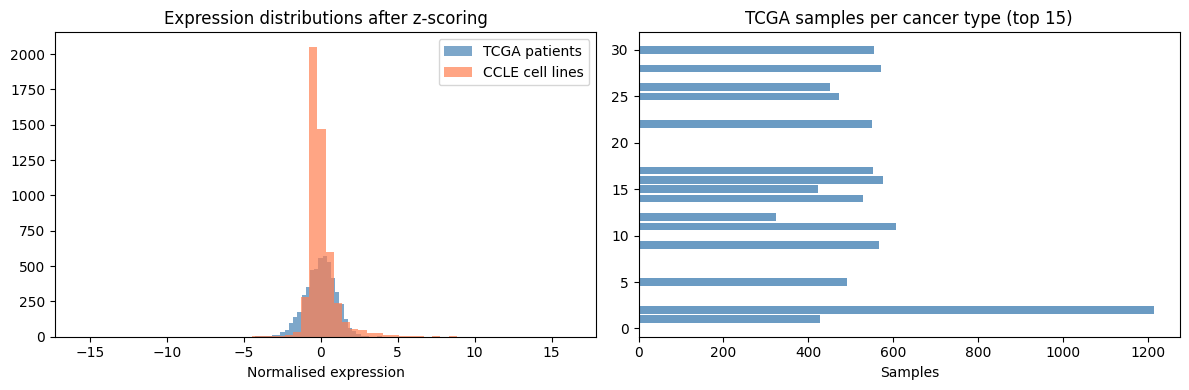

In [ ]:
# QC figure: compare expression distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sample 5000 values from each for speed
tcga_sample = tcga_norm.values.flatten()[
    np.random.choice(tcga_norm.size, 5000, replace=False)
]
ccle_sample = ccle_norm.values.flatten()[
    np.random.choice(ccle_norm.size, 5000, replace=False)
]

axes[0].hist(tcga_sample, bins=60, alpha=0.7, color='steelblue', label='TCGA patients')
axes[0].hist(ccle_sample, bins=60, alpha=0.7, color='coral', label='CCLE cell lines')
axes[0].set_xlabel('Normalised expression')
axes[0].set_title('Expression distributions after z-scoring')
axes[0].legend()

# Cancer type distribution in TCGA
ct_counts = tcga_clin['cancer_type'].value_counts()
axes[1].barh(ct_counts.index[:15], ct_counts.values[:15], color='steelblue', alpha=0.8)
axes[1].set_xlabel('Samples')
axes[1].set_title('TCGA samples per cancer type (top 15)')

plt.tight_layout()
plt.savefig('figures/01_harmonisation_qc.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4 — Build resistance labels for GDSC2 cell lines

For the contrastive model we need to define which cell lines are
'resistant' vs 'sensitive' to each drug class.

Strategy: for each pathway group (e.g. EGFR inhibitors, PARP inhibitors),
take the mean IC50 across drugs in that group per cell line.
Top 33% = resistant, bottom 33% = sensitive, middle = excluded.

This gives us biologically meaningful contrastive pairs:
two resistant cell lines = positive pair (should be close in latent space)
resistant vs sensitive = negative pair (should be far apart)

In [ ]:
# Group drugs by pathway using GDSC2 PATHWAY_NAME column
ic50_raw = pd.read_excel('data/GDSC2_fitted_dose_response_27Oct23.xlsx', engine='openpyxl')

pathway_groups = (
    ic50_raw[['DRUG_NAME', 'PATHWAY_NAME']]
    .drop_duplicates()
    .dropna(subset=['PATHWAY_NAME'])
)

print('Drug pathway groups:')
print(pathway_groups['PATHWAY_NAME'].value_counts().head(15))

Drug pathway groups:
PATHWAY_NAME
Unclassified                         34
Other                                28
PI3K/MTOR signaling                  26
Other, kinases                       22
DNA replication                      20
Genome integrity                     13
ERK MAPK signaling                   13
Apoptosis regulation                 13
Cell cycle                           13
RTK signaling                        12
Chromatin histone methylation        12
Chromatin histone acetylation        10
Chromatin other                      10
Protein stability and degradation     9
WNT signaling                         9
Name: count, dtype: int64


In [ ]:
ic50_z = pd.read_parquet('data/gdsc2_ic50.parquet')

In [ ]:
# For each pathway, compute mean IC50 across cell lines
# and assign resistant / sensitive / middle labels

resistance_labels = pd.DataFrame(index=ic50_z.index)

for pathway, group_df in pathway_groups.groupby('PATHWAY_NAME'):
    drugs_in_pathway = [d for d in group_df['DRUG_NAME'].tolist() if d in ic50_z.columns]
    if len(drugs_in_pathway) < 2:
        continue

    mean_ic50 = ic50_z[drugs_in_pathway].mean(axis=1)

    q33 = mean_ic50.quantile(0.33)
    q67 = mean_ic50.quantile(0.67)

    label = pd.Series('middle', index=ic50_z.index)
    label[mean_ic50 >= q67] = 'resistant'
    label[mean_ic50 <= q33] = 'sensitive'

    # Clean pathway name for column
    col = pathway.replace(' ', '_').replace('/', '_').lower()
    resistance_labels[col] = label

print(f'Resistance label matrix: {resistance_labels.shape}')
print('Pathways:', resistance_labels.columns.tolist())
print()
print('Label distribution (first pathway):')
print(resistance_labels.iloc[:, 0].value_counts())

Resistance label matrix: (965, 23)
Pathways: ['apoptosis_regulation', 'cell_cycle', 'chromatin_histone_acetylation', 'chromatin_histone_methylation', 'chromatin_other', 'cytoskeleton', 'dna_replication', 'egfr_signaling', 'erk_mapk_signaling', 'genome_integrity', 'hormone-related', 'igf1r_signaling', 'jnk_and_p38_signaling', 'metabolism', 'mitosis', 'other', 'other,_kinases', 'pi3k_mtor_signaling', 'protein_stability_and_degradation', 'rtk_signaling', 'unclassified', 'wnt_signaling', 'p53_pathway']

Label distribution (first pathway):
apoptosis_regulation
middle       327
resistant    319
sensitive    319
Name: count, dtype: int64


In [ ]:
# Save everything
tcga_norm.to_parquet('data/tcga_expr_norm.parquet')
ccle_norm.to_parquet('data/ccle_expr_norm.parquet')
resistance_labels.to_csv('data/resistance_labels.csv')

# Also save the shared gene list — needed in notebook 02
pd.Series(shared_genes).to_csv('data/shared_genes.csv', index=False, header=False)

print('Saved:')
print(f'  data/tcga_expr_norm.parquet   {tcga_norm.shape}')
print(f'  data/ccle_expr_norm.parquet   {ccle_norm.shape}')
print(f'  data/resistance_labels.csv    {resistance_labels.shape}')
print(f'  data/shared_genes.csv         {len(shared_genes)} genes')
print()
print('Next: 02_representation_learning.ipynb')

Saved:
  data/tcga_expr_norm.parquet   (11060, 97)
  data/ccle_expr_norm.parquet   (486, 97)
  data/resistance_labels.csv    (965, 23)
  data/shared_genes.csv         97 genes

Next: 02_representation_learning.ipynb
